# Undersampling on the full credit-card dataset

Re-run for #18/#19/#20. The earlier experiments loaded a 20k-majority subsample, which is itself random undersampling and hid the effect. On the whole **284,807-row** dataset (~0.17% positive) we compare the ways of correcting for the extreme imbalance:

- **baseline** — no correction (full data)
- **class_weight** — balanced sample weights (full data)
- **rus_r** — random undersampling to *r* negatives per positive
- **rus_r_wt** — rus plus prior-restoring weights (recover the original prior)

on Random Forest and XGBoost, over 3 seeds, with threshold-free metrics (ROC-AUC, average precision), calibration (Brier, mean predicted probability) and training time. The questions: does undersampling beat a properly class-corrected baseline (Elkan says no), how much time does it save, and do the prior-restoring weights recover calibration.

In [1]:
import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
os.makedirs('../figures', exist_ok=True)

with open('../models/undersampling-creditcard-full/results.pkl', 'rb') as f:
    res = pickle.load(f)
runs = pd.DataFrame(res['runs'])
true_prior = res['meta']['test_prior']
g = runs.groupby(['learner', 'method'], sort=False)
summary = g[['roc', 'ap', 'brier', 'mean_prob', 'fit_time_s']].mean().round(4)
summary['roc_sd'] = g['roc'].std().round(4)
summary['ap_sd'] = g['ap'].std().round(4)
summary

roc      ap   brier  mean_prob  fit_time_s  roc_sd  \
learner method                                                                
rf      baseline      0.9511  0.8340  0.0004     0.0017     24.9621  0.0040   
        class_weight  0.9577  0.8383  0.0004     0.0020     10.3507  0.0020   
        rus_1         0.9752  0.7472  0.0304     0.1114      0.1126  0.0027   
        rus_1_wt      0.9483  0.6566  0.0011     0.0020      0.1081  0.0135   
        rus_10        0.9769  0.7612  0.0025     0.0183      0.2450  0.0037   
        rus_10_wt     0.9477  0.7221  0.0007     0.0021      0.1666  0.0017   
        rus_100       0.9623  0.8082  0.0006     0.0035      2.9508  0.0006   
        rus_100_wt    0.9518  0.7900  0.0005     0.0019      2.3657  0.0060   
xgb     baseline      0.9294  0.7311  0.0006     0.0014      2.4185  0.0000   
        class_weight  0.9720  0.8508  0.0004     0.0016      2.2275  0.0000   
        rus_1         0.9790  0.7401  0.0263     0.0478      0.0452  0.0030   
        rus_1_wt      0.9651  0.1385  0.0337     0.0405      0.0903  0.0138   
        rus_10        0.9790  0.7766  0.0017     0.0047      0.0973  0.0016   
        rus_10_wt     0.9502  0.3320  0.0117     0.0139      0.1990  0.0303   
        rus_100       0.9756  0.8408  0.0006     0.0019      0.4815  0.0012   
        rus_100_wt    0.7640  0.3564  0.0023     0.0023      0.4900  0.2398   

                       ap_sd  
learner method                
rf      baseline      0.0042  
        class_weight  0.0054  
        rus_1         0.0229  
        rus_1_wt      0.0380  
        rus_10        0.0326  
        rus_10_wt     0.0175  
        rus_100       0.0152  
        rus_100_wt    0.0152  
xgb     baseline      0.0000  
        class_weight  0.0000  
        rus_1         0.0246  
        rus_1_wt      0.0538  
        rus_10        0.0196  
        rus_10_wt     0.2933  
        rus_100       0.0053  
        rus_100_wt    0.3711

## Discrimination: ROC-AUC and average precision

Undersampling matches class weights on ROC, but class weights is clearly better on average precision, because undersampling throws away 99%+ of the majority. The dashed line is the class-weighted full-data model (the fair reference).

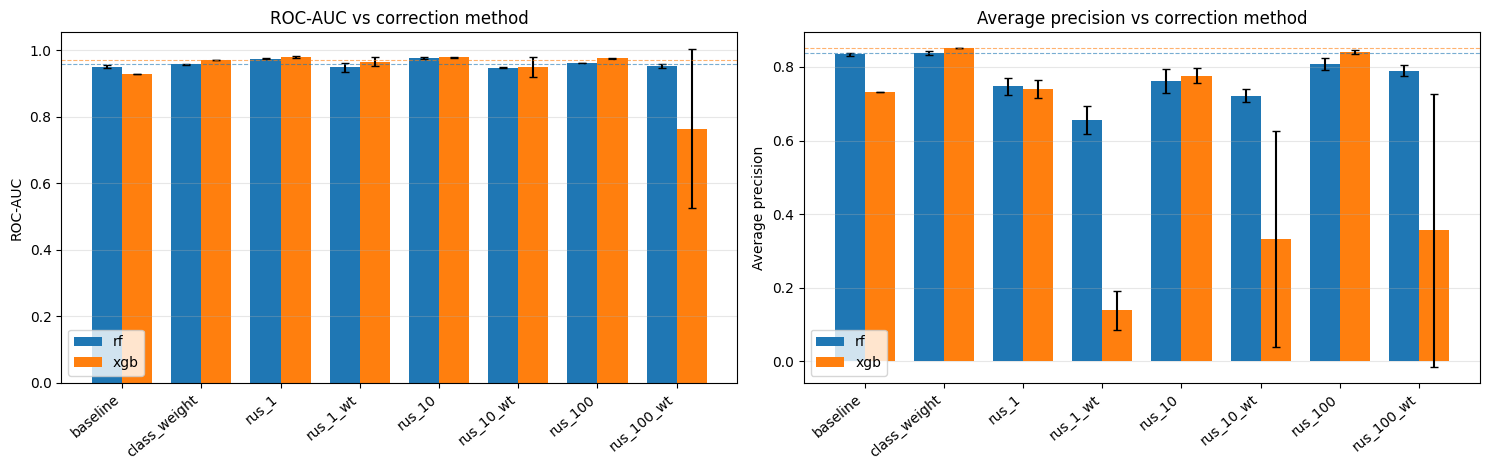

In [2]:
order = ['baseline', 'class_weight', 'rus_1', 'rus_1_wt', 'rus_10', 'rus_10_wt', 'rus_100', 'rus_100_wt']
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, metric, title in [(axes[0], 'roc', 'ROC-AUC'), (axes[1], 'ap', 'Average precision')]:
    width = 0.38
    for i, ln in enumerate(['rf', 'xgb']):
        sub = runs[runs.learner == ln].groupby('method')[metric]
        m = sub.mean().reindex(order); s = sub.std().reindex(order)
        ax.bar(np.arange(len(order)) + (i - 0.5) * width, m, width, yerr=s, capsize=3, label=ln)
        cw = runs[(runs.learner == ln) & (runs.method == 'class_weight')][metric].mean()
        ax.axhline(cw, ls='--', lw=0.8, color=('tab:blue' if ln == 'rf' else 'tab:orange'), alpha=0.6)
    ax.set_xticks(np.arange(len(order))); ax.set_xticklabels(order, rotation=40, ha='right')
    ax.set_ylabel(title); ax.set_title(f'{title} vs correction method'); ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('../figures/rerun_credit_perf.png', dpi=150, bbox_inches='tight')
plt.show()

## Calibration and speed

Unweighted undersampling overpredicts badly (mean predicted probability far above the true 0.17%); the prior-restoring weights pull it back. But the reweighting can also destabilise the model (note the XGBoost `rus_*_wt` variance). Meanwhile undersampling trains one to three orders of magnitude faster than the full-data models.

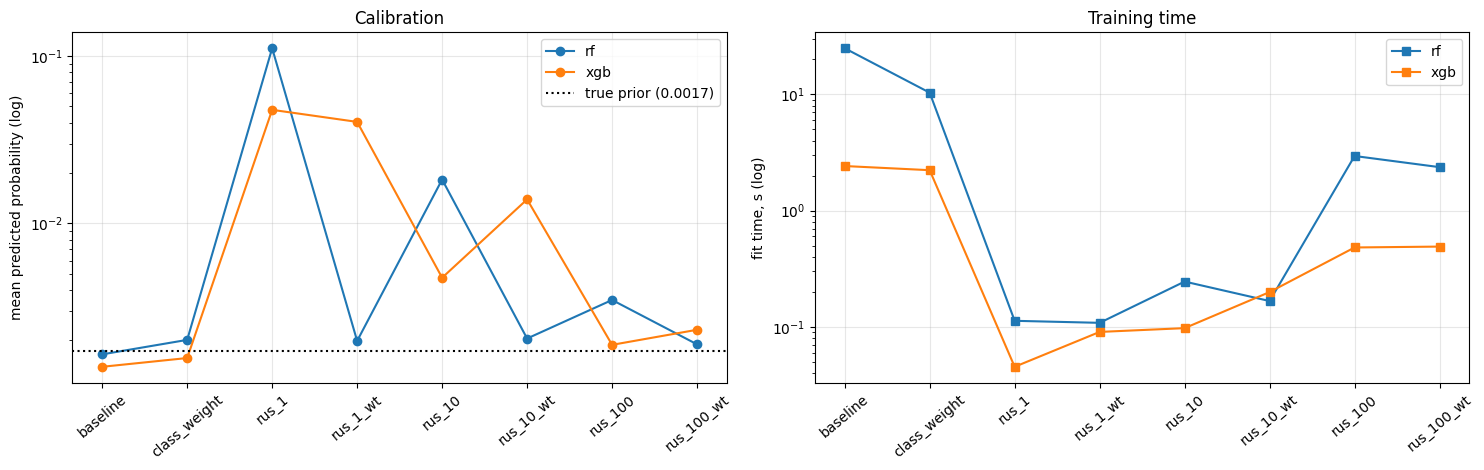

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for i, ln in enumerate(['rf', 'xgb']):
    mp = runs[runs.learner == ln].groupby('method')['mean_prob'].mean().reindex(order)
    axes[0].plot(order, mp, 'o-', label=ln)
    ft = runs[runs.learner == ln].groupby('method')['fit_time_s'].mean().reindex(order)
    axes[1].plot(order, ft, 's-', label=ln)
axes[0].axhline(true_prior, ls=':', color='k', label=f'true prior ({true_prior:.4f})')
axes[0].set_yscale('log'); axes[0].set_ylabel('mean predicted probability (log)')
axes[0].set_title('Calibration'); axes[0].tick_params(axis='x', rotation=40)
axes[1].set_yscale('log'); axes[1].set_ylabel('fit time, s (log)')
axes[1].set_title('Training time'); axes[1].tick_params(axis='x', rotation=40)
for a in axes: a.legend(); a.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('../figures/rerun_credit_calib_speed.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

On the full 284k creditcard, this refines the picture rather than overturning it, and lines up with Elkan.

1. **The naive baseline is only weak for some learners.** XGBoost underfits the 0.17% minority (AP 0.73) and class weights fix it (AP 0.85); Random Forest's baseline is already strong (ROC 0.95, AP 0.83, and calibrated), so the 'naive fails on extreme imbalance' effect is real but model-dependent.
2. **Undersampling ties class weights on ROC but loses on average precision.** Both correct the imbalance and land at ROC ~0.95-0.98, but undersampling throws away 99%+ of the majority, so its AP is lower and noisier (RUS ~0.74-0.84 vs class weights ~0.85). Class weights is the better correction on the full data.
3. **Undersampling's real advantage is speed** (100-600x faster here), which is the case for using it on genuinely large data.
4. **Prior-restoring weights recover calibration but can destabilise.** They pull the mean predicted probability back to the true prior, but the heavy reweighting hurts XGBoost badly at aggressive ratios (AP collapses, variance explodes), so they need moderate ratios and a robust learner.

So the 'undersampling win' over the naive model is really the win of **class correction** (undersampling, class weights and threshold-moving are the equivalent ways, per Elkan); undersampling is not better than class weights except on training time. The 2.4% subsample hid the need for correction because it was not imbalanced enough for the naive model to fail.

*RandomUnderSampler only here (the fast, tractable case). The cleaning undersamplers and special ensembles on the full data are the slow tail, still to run.*